<a href="https://colab.research.google.com/github/rercampos/PreparandoAmbiente/blob/main/Aquisi%C3%A7%C3%A3o_e_Prepara%C3%A7%C3%A3o_de_Dados_Aplicando_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **APLICANDO O CONHECIMENTO 8**

**COMPONENTE CURRICULAR**: Aquisição e Preparação de Dados

**NOME COMPLETO DO ALUNO**: Reginaldo Rogério de Campos

**RA**: 10743942

# **Pipeline de Preparação de Dados Aplicado à Análise de Doenças Cardíacas**

**1.	INTRODUÇÃO**

A análise de dados na área da saúde possui grande importância para auxiliar na identificação de padrões, apoio à tomada de decisão e compreensão de fatores relacionados às doenças. Entretanto, antes da utilização dos dados em análises e modelos, é necessário realizar processos de limpeza e preparação para garantir maior qualidade e confiabilidade das informações.
Neste trabalho foi desenvolvido um pipeline de preparação de dados utilizando uma base relacionada a doenças cardíacas. O processo envolveu análise exploratória, identificação de inconsistências, tratamento de duplicidades e outliers, transformação dos dados e geração de visualizações para análise dos resultados.


**2.	DESCRIÇÃO DA BASE DE DADOS**

A base de dados utilizada neste trabalho foi a Heart Disease Dataset (Kaggle), disponibilizada publicamente na plataforma Kaggle. O conjunto de dados reúne informações clínicas de pacientes utilizadas em estudos relacionados à identificação e análise de doenças cardíacas.

Os dados representam informações obtidas durante avaliações médicas e exames clínicos realizados em pacientes, contendo variáveis associadas a fatores cardiovasculares, condições clínicas e resultados de exames diagnósticos. O principal objetivo da base é auxiliar na análise de características que podem estar relacionadas à presença de doenças cardíacas.

Inicialmente, a base possuía 1025 registros e 14 atributos. Durante o processo de preparação dos dados foram identificados registros duplicados e valores extremos (outliers), que posteriormente foram tratados para melhorar a qualidade e consistência dos dados.

Os atributos presentes na base incluem informações como idade, sexo, pressão arterial, colesterol, frequência cardíaca máxima atingida, tipo de dor no peito e presença de angina induzida por exercício. Além disso, a variável target indica a presença ou ausência de doença cardíaca no paciente analisado, sendo considerada a variável alvo da análise.

A utilização dessa base é relevante para estudos de análise de dados na área da saúde, pois permite identificar padrões e relações entre fatores clínicos e doenças cardiovasculares, contribuindo para análises estatísticas e apoio à tomada de decisão.



https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset?utm_source=chatgpt.com


**2.1 Descrição da Base de Dados**

A seguir são apresentados os principais atributos presentes na base de dados utilizada no projeto

| Atributo | Descrição                                       |
| -------- | ----------------------------------------------- |
| age      | Idade do paciente                               |
| sex      | Sexo do paciente                                |
| cp       | Tipo de dor no peito                            |
| trestbps | Pressão arterial em repouso                     |
| chol     | Colesterol sérico                               |
| fbs      | Glicemia em jejum                               |
| restecg  | Resultado do eletrocardiograma em repouso       |
| thalach  | Frequência cardíaca máxima atingida             |
| exang    | Angina induzida por exercício                   |
| oldpeak  | Depressão do segmento ST induzida por exercício |
| slope    | Inclinação do segmento ST                       |
| ca       | Número de vasos principais observados           |
| thal     | Resultado do exame thalassemia                  |
| target   | Presença ou ausência de doença cardíaca         |


**Importação das bibliotecas**

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Upload do CSV**

In [61]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart (2).csv


**3. ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)**


A análise exploratória dos dados foi realizada com o objetivo de compreender a estrutura da base, identificar possíveis inconsistências e obter uma visão inicial sobre as características das variáveis presentes no conjunto de dados. Essa etapa é fundamental no processo de preparação de dados, pois permite detectar problemas que podem comprometer a qualidade das análises posteriores.

Inicialmente, foram utilizadas funções como df.info() e df.describe() para verificar informações gerais da base, incluindo quantidade de registros, tipos de dados e estatísticas descritivas das variáveis numéricas. A análise mostrou que a base possuía inicialmente 1025 registros e 14 atributos, contendo principalmente variáveis numéricas relacionadas a indicadores clínicos e cardiovasculares.

A verificação dos tipos de dados demonstrou que todas as variáveis estavam corretamente estruturadas em formato numérico, facilitando a aplicação das técnicas de análise estatística e preparação dos dados. Também foi possível observar medidas estatísticas importantes, como média, desvio padrão, valores mínimos, máximos e quartis das variáveis clínicas.

**Base de dados**

In [62]:
# Leitura da base de dados

df = pd.read_csv('heart.csv')

# Exibir as 5 primeiras linhas

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


**Tamanho da base de dados**

In [63]:
# Quantidade de linhas e colunas

df.shape

(1025, 14)

**Informações gerais**

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


**Estatística descritiva inicial**

In [65]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**Nome das colunas**

In [66]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

**Valores Ausentes**

Em seguida, foi realizada a análise de valores ausentes utilizando a função df.isnull().sum(). O resultado indicou que a base não apresentava dados faltantes, demonstrando boa integridade estrutural dos registros coletados.

In [67]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


**Valores Duplicados**

Apesar da ausência de valores ausentes, a análise exploratória identificou um problema relevante relacionado à duplicidade de dados. A utilização da função df.duplicated().sum() revelou a existência de 723 registros duplicados. A presença dessas duplicidades poderia causar distorções estatísticas, influenciar distribuições das variáveis e comprometer a confiabilidade das análises.

In [68]:
df.duplicated().sum()

np.int64(723)

**Remoção de Duplicidades**

Para resolver esse problema, foi utilizada a função drop_duplicates(), responsável por remover os registros repetidos e manter apenas dados únicos.

Após esse processo, a base foi reduzida de 1025 para aproximadamente 302 registros, tornando os dados mais consistentes e confiáveis para as etapas seguintes do pipeline de preparação.



In [69]:
df = df.drop_duplicates()

Confirmação da remoção dos duplicados

In [70]:
df.duplicated().sum()

np.int64(0)

**Novo tamanho da base**

In [71]:
df.shape

(302, 14)

**Identificação de Outliers com Boxplots**

Após a remoção das duplicidades, foram utilizados gráficos do tipo boxplot para auxiliar na identificação de possíveis outliers nas variáveis numéricas da base de dados.

Os boxplots permitem visualizar a distribuição dos dados, a dispersão das variáveis e valores que se encontram muito distantes da maioria das observações. Esses valores extremos podem influenciar negativamente análises estatísticas e comprometer a interpretação dos resultados.

A utilização dos boxplots facilitou a identificação visual de outliers em atributos como pressão arterial, colesterol, frequência cardíaca máxima e oldpeak, auxiliando na definição da estratégia de tratamento aplicada posteriormente no pipeline de preparação dos dados.

**Criação do Boxplots**

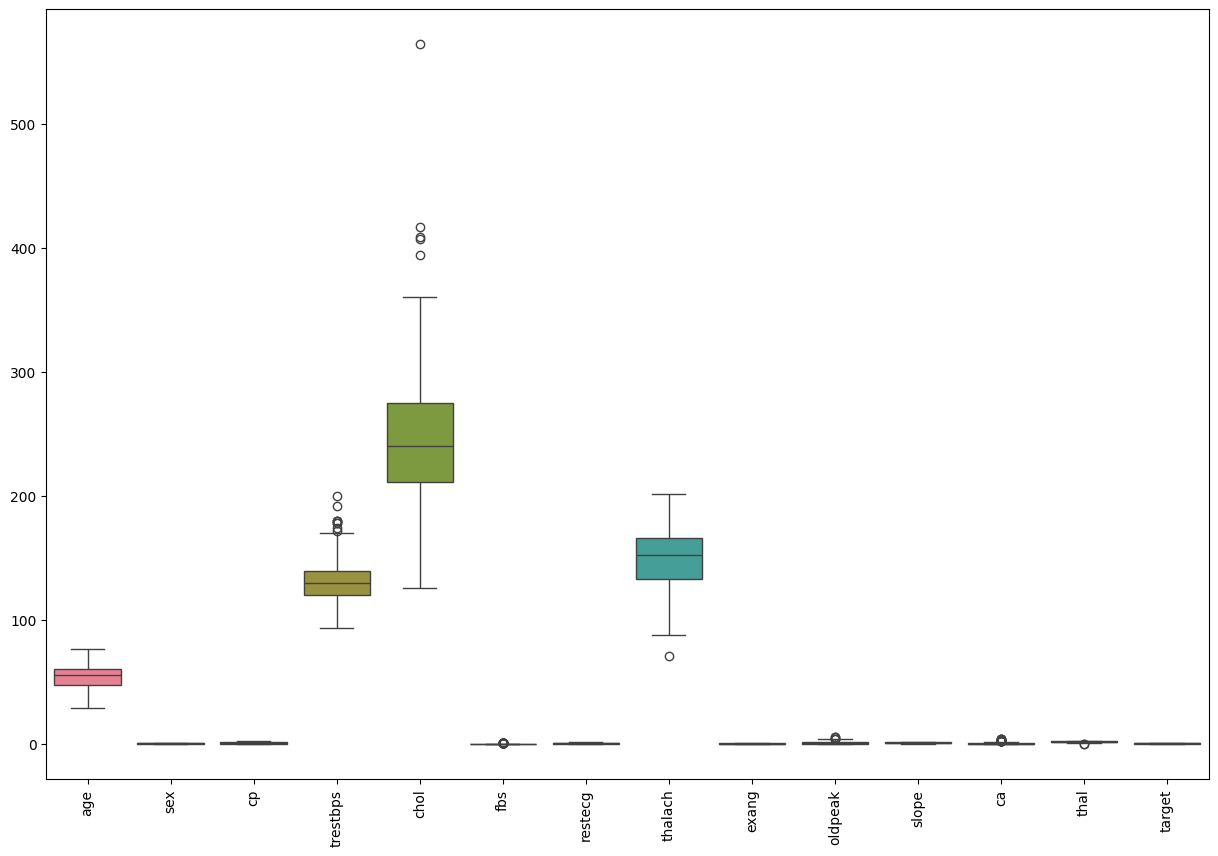

In [72]:
# Boxplots das variáveis numéricas

plt.figure(figsize=(15,10))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

**Identificação dos Outliers com IQR**

Após a análise visual realizada com os boxplots, foi utilizado o método do Intervalo Interquartil (IQR) para identificar valores extremos nas variáveis numéricas da base de dados.

O método IQR consiste em calcular a diferença entre o terceiro quartil (Q3) e o primeiro quartil (Q1), permitindo definir limites inferiores e superiores para identificação de outliers. Valores localizados fora desses limites são considerados extremos.

Foram analisadas variáveis como idade, pressão arterial, colesterol, frequência cardíaca máxima e oldpeak. A aplicação do método permitiu identificar a presença de outliers principalmente nas variáveis relacionadas à pressão arterial, colesterol e oldpeak.

Essa etapa foi importante para reduzir possíveis distorções estatísticas e melhorar a consistência dos dados utilizados nas análises posteriores.

In [73]:
# Selecionar colunas numéricas

colunas_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Detectar outliers usando IQR

for coluna in colunas_numericas:

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[coluna] < limite_inferior) |
                  (df[coluna] > limite_superior)]

    print(f'{coluna}: {len(outliers)} outliers')

age: 0 outliers
trestbps: 9 outliers
chol: 5 outliers
thalach: 1 outliers
oldpeak: 5 outliers


**Remoção dos Outliers com IQR**

Após a identificação dos valores extremos pelo método IQR, foi realizado o processo de remoção dos outliers das variáveis numéricas analisadas.

Foram mantidos apenas os registros que estavam dentro dos limites definidos pelo intervalo interquartil, reduzindo a influência de valores extremos que poderiam comprometer as análises estatísticas e as visualizações da base de dados.

Após esse processo, a base passou de aproximadamente 302 para 283 registros, resultando em um conjunto de dados mais consistente e adequado para as etapas seguintes do pipeline de preparação dos dados.

In [74]:
# Remoção dos outliers usando IQR

for coluna in colunas_numericas:

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df = df[(df[coluna] >= limite_inferior) &
            (df[coluna] <= limite_superior)]

**Novo tamanho da base**

In [75]:
df.shape

(283, 14)

**4. TRANSFORMAÇÃO DOS DADOS E PADRONIZAÇÃO DAS VARIÁVEIS**

Após as etapas de limpeza da base de dados, foi realizado o processo de transformação dos dados por meio da padronização das variáveis numéricas. Essa etapa teve como objetivo colocar os atributos em uma mesma escala, reduzindo diferenças de magnitude entre as variáveis e facilitando análises posteriores.

Inicialmente, foram selecionadas as principais colunas numéricas da base, incluindo variáveis como idade (age), pressão arterial (trestbps), colesterol (chol), frequência cardíaca máxima (thalach) e oldpeak.

Em seguida, foi aplicada a técnica de padronização utilizando o StandardScaler, disponível na biblioteca scikit-learn. Esse método transforma os dados para que apresentem média próxima de zero e desvio padrão igual a um.

A padronização foi importante para tornar as variáveis mais comparáveis entre si, evitando que atributos com escalas maiores exercessem maior influência nas análises.

Após a aplicação da transformação, as variáveis numéricas passaram a apresentar valores padronizados, contribuindo para uma base de dados mais organizada e adequada para análise estatística e visualização dos resultados.



**Padronização das variáveis numéricas**

In [76]:
#Importar StandardScaler
from sklearn.preprocessing import StandardScaler

**Seleção das colunas numéricas**

In [77]:
# Colunas numéricas

colunas_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

**Padronização**

In [78]:
# Criar objeto scaler

scaler = StandardScaler()

# Aplicar padronização

df[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])

**Resultado da Padronização**

In [79]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-0.224919,1,0,-0.317917,-0.680075,0,1,0.796365,0,0.046903,2,2,3,0
1,-0.115174,1,0,0.658608,-0.881981,1,0,0.222452,1,2.096513,0,0,3,0
2,1.750489,1,0,0.984117,-1.532566,0,1,-1.101964,1,1.608511,0,0,3,0
3,0.762785,1,0,1.179422,-0.881981,0,1,0.487335,0,-0.929101,2,1,3,0
4,0.872530,0,0,0.528405,1.159512,1,1,-1.940760,0,0.925307,1,3,2,0


**5. REDUÇÃO DA DIMENSIONALIDADE E SELEÇÃO DE ATRIBUTOS**

A etapa de redução de dimensionalidade foi realizada por meio da análise de correlação entre as variáveis da base de dados. O objetivo desse processo foi identificar os atributos mais relevantes para a análise da presença de doenças cardíacas, reduzindo a influência de variáveis menos significativas.

Para isso, foi utilizada uma matriz de correlação, permitindo avaliar o grau de relacionamento entre os atributos clínicos e a variável alvo target, responsável por indicar a presença ou ausência de doença cardíaca.

Os resultados mostraram que as variáveis relacionadas à frequência cardíaca máxima atingida e ao tipo de dor no peito apresentaram as maiores correlações positivas com a variável alvo, indicando maior relevância para análise cardiovascular. Além disso, variáveis relacionadas à depressão do segmento ST induzida por exercício, presença de angina induzida por exercício e quantidade de vasos principais observados apresentaram correlações negativas moderadas, demonstrando influência significativa na identificação da doença cardíaca.

Por outro lado, atributos relacionados à glicemia em jejum, colesterol sérico e pressão arterial em repouso apresentaram correlações mais fracas com a variável alvo, indicando menor influência na análise realizada.

Além da relação com a variável alvo, a matriz de correlação também permitiu identificar relações entre os próprios atributos clínicos, auxiliando na compreensão do comportamento geral da base de dados.

De maneira geral, essa etapa contribuiu para identificar os atributos mais relevantes da base e auxiliar no processo de seleção de variáveis, tornando a análise dos dados mais organizada e eficiente.



**Matriz de Correlação**

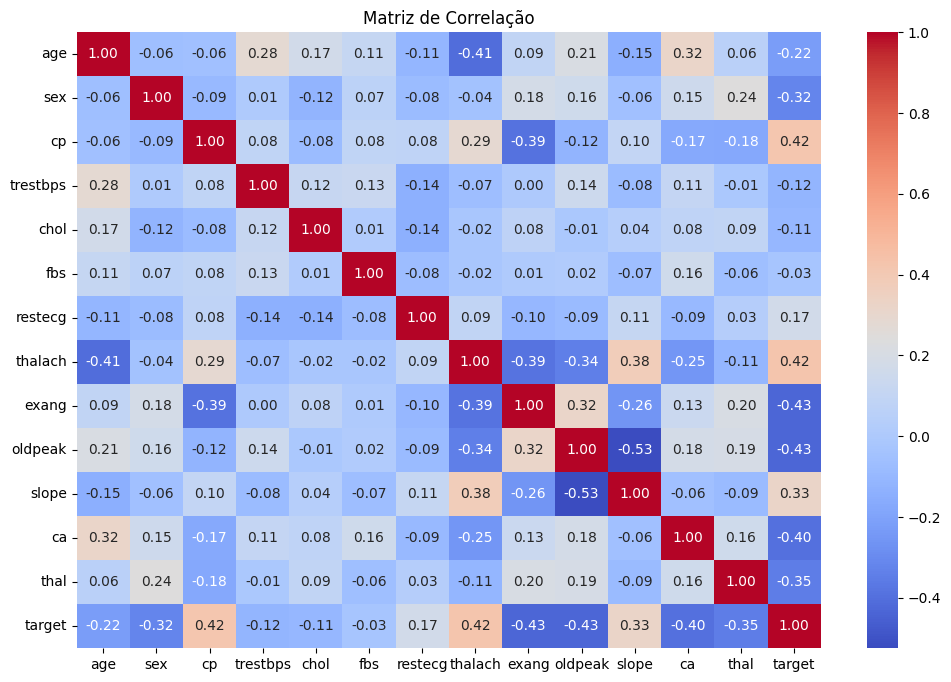

In [80]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Matriz de Correlação')

plt.show()

**Identificação dos atributos mais relevantes**

In [81]:
# Correlação com a variável target

correlacao_target = df.corr()['target'].sort_values(ascending=False)

print(correlacao_target)

target      1.000000
thalach     0.422559
cp          0.416319
slope       0.326473
restecg     0.171453
fbs        -0.027210
chol       -0.105627
trestbps   -0.115614
age        -0.222416
sex        -0.318896
thal       -0.349150
ca         -0.397733
exang      -0.431599
oldpeak    -0.434108
Name: target, dtype: float64


**6. VISUALIZAÇÕES FINAIS DA BASE PREPARADA**

Após a conclusão das etapas de limpeza, tratamento e transformação dos dados, foram geradas visualizações gráficas com o objetivo de analisar o comportamento das variáveis e compreender melhor os padrões presentes na base preparada.

**Informações gerais da base preparada**

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       283 non-null    float64
 1   sex       283 non-null    int64  
 2   cp        283 non-null    int64  
 3   trestbps  283 non-null    float64
 4   chol      283 non-null    float64
 5   fbs       283 non-null    int64  
 6   restecg   283 non-null    int64  
 7   thalach   283 non-null    float64
 8   exang     283 non-null    int64  
 9   oldpeak   283 non-null    float64
 10  slope     283 non-null    int64  
 11  ca        283 non-null    int64  
 12  thal      283 non-null    int64  
 13  target    283 non-null    int64  
dtypes: float64(5), int64(9)
memory usage: 33.2 KB


**Estatística descritiva final**

In [83]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,2.830000e+02,283.000000,283.000000,2.830000e+02,2.830000e+02,283.000000,283.000000,2.830000e+02,283.000000,2.830000e+02,283.000000,283.000000,283.000000,283.000000
mean,-3.452284e-17,0.699647,0.985866,5.335347e-16,-2.102755e-16,0.141343,0.522968,-3.044286e-16,0.318021,5.649191e-17,1.427562,0.696113,2.296820,0.558304
std,1.001771e+00,0.459224,1.031324,1.001771e+00,1.001771e+00,0.348992,0.514336,1.001771e+00,0.466533,1.001771e+00,0.599246,0.985472,0.610392,0.497469
min,-2.749050e+00,0.000000,0.000000,-2.336070e+00,-2.609398e+00,0.000000,0.000000,-2.735410e+00,0.000000,-9.291011e-01,0.000000,0.000000,0.000000,0.000000
25%,-7.736431e-01,0.000000,0.000000,-6.434256e-01,-7.137258e-01,0.000000,0.000000,-7.267127e-01,0.000000,-9.291011e-01,1.000000,0.000000,2.000000,0.000000
50%,1.043158e-01,1.000000,1.000000,7.591363e-03,-7.435717e-02,0.000000,1.000000,1.341575e-01,0.000000,-3.434984e-01,1.000000,0.000000,2.000000,1.000000
75%,6.530401e-01,1.000000,2.000000,6.586083e-01,6.323134e-01,0.000000,1.000000,7.963654e-01,1.000000,6.325061e-01,2.000000,1.000000,3.000000,1.000000
max,2.518703e+00,1.000000,3.000000,2.611659e+00,2.640155e+00,1.000000,2.000000,2.297370e+00,1.000000,2.974917e+00,2.000000,4.000000,3.000000,1.000000


**Verificação de valores ausentes**

In [84]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


**Verificação de duplicados**

In [85]:
df.duplicated().sum()

np.int64(0)

**Histograma**

Os histogramas foram utilizados para analisar a distribuição das variáveis da base de dados após as etapas de limpeza e preparação dos dados. Essa visualização permitiu compreender o comportamento das variáveis, identificar padrões de concentração e verificar a dispersão dos valores.

A variável relacionada à idade apresentou distribuição relativamente equilibrada, com maior concentração de pacientes em faixas etárias intermediárias. Já a variável de pressão arterial em repouso apresentou distribuição próxima de um comportamento normal, sem grande presença de valores extremos após o tratamento dos outliers.

A variável colesterol sérico também apresentou distribuição relativamente centralizada, indicando que a maior parte dos pacientes possui valores próximos à média observada na base. A frequência cardíaca máxima atingida mostrou distribuição moderadamente concentrada, com maior quantidade de registros em valores intermediários.

Algumas variáveis categóricas, como sexo, glicemia em jejum, presença de angina induzida por exercício e variável alvo (target), apresentaram distribuições discretas, o que é esperado devido à natureza binária dessas informações.

Além disso, variáveis relacionadas ao tipo de dor no peito, inclinação do segmento ST e quantidade de vasos principais observados apresentaram distribuições variadas entre suas categorias, demonstrando diversidade de características clínicas entre os pacientes analisados.

De maneira geral, os histogramas mostraram que a base preparada apresentou distribuições mais organizadas e consistentes após as etapas de remoção de duplicidades, tratamento de outliers e padronização das variáveis numéricas, contribuindo para análises mais confiáveis dos dados cardiovasculares.



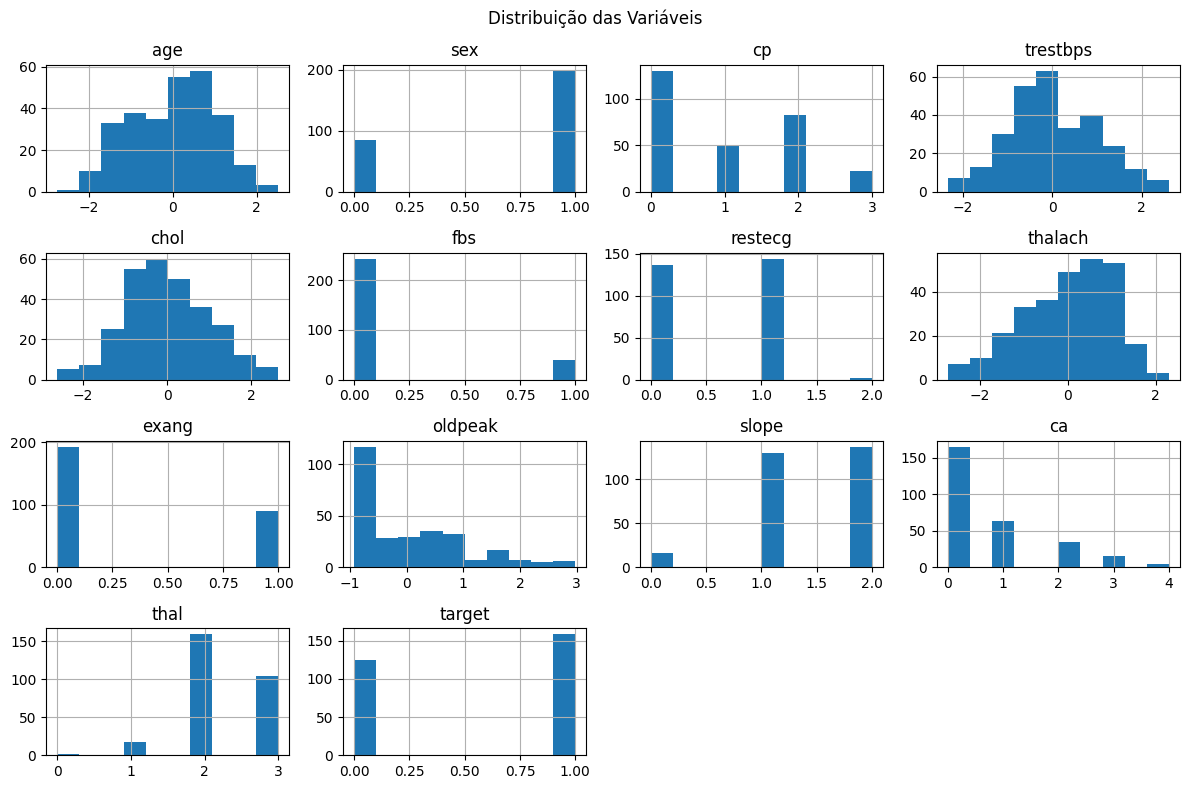

In [86]:
df.hist(figsize=(12,8))

plt.suptitle('Distribuição das Variáveis')

plt.tight_layout()

plt.show()

**Boxplots finais**

O boxplot das variáveis foi utilizado para analisar a dispersão dos dados e verificar a presença de possíveis outliers após o processo de limpeza e preparação da base de dados.

De maneira geral, observa-se que a maior parte das variáveis apresentou distribuição relativamente equilibrada, indicando que o tratamento dos outliers realizado anteriormente contribuiu para reduzir valores extremos na base de dados.

As variáveis relacionadas à idade, pressão arterial em repouso, colesterol sérico e frequência cardíaca máxima apresentaram dispersão moderada, demonstrando variabilidade esperada em dados clínicos de pacientes. Já algumas variáveis categóricas, como sexo, glicemia em jejum e presença de angina induzida por exercício, apresentaram distribuição mais concentrada devido à natureza discreta dos seus valores.

Também é possível observar a presença de poucos pontos isolados em algumas variáveis, indicando que ainda existem valores extremos residuais. Entretanto, esses valores não aparecem em quantidade significativa e podem representar características reais dos pacientes analisados, sendo aceitáveis dentro do contexto clínico da base.

De forma geral, o boxplot demonstrou que a base preparada ficou mais consistente após as etapas de remoção de duplicidades, tratamento de outliers e padronização das variáveis numéricas, tornando os dados mais adequados para análise estatística e interpretação dos resultados.

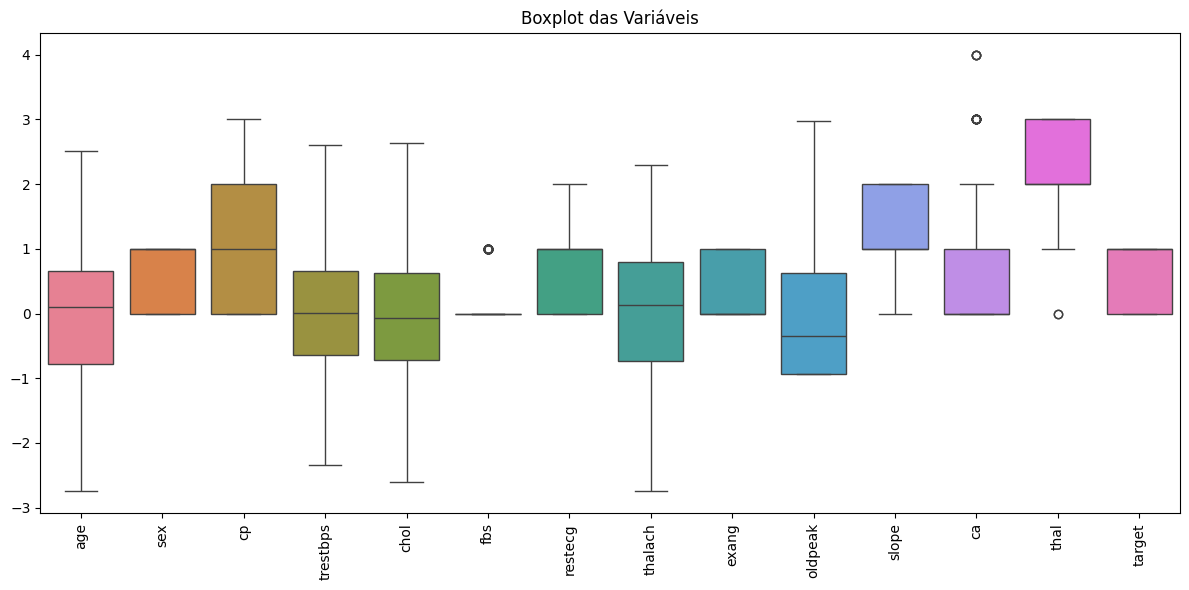

In [87]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title('Boxplot das Variáveis')

plt.tight_layout()

plt.show()

**Gráfico de contagem do target**

O gráfico de contagem da variável target foi utilizado para visualizar a distribuição dos pacientes em relação à presença ou ausência de doença cardíaca na base de dados preparada.

Observa-se que a categoria correspondente à presença de doença cardíaca (target = 1) apresentou quantidade ligeiramente maior de registros em comparação à categoria sem doença cardíaca (target = 0). Isso indica que a base possui uma distribuição relativamente equilibrada entre as duas classes, sem grande desbalanceamento dos dados.

Essa característica é importante para análises estatísticas e estudos relacionados à identificação de padrões cardiovasculares, pois permite comparar os grupos de forma mais adequada e reduz possíveis impactos causados por excesso de registros em apenas uma categoria.

O gráfico também demonstra que, mesmo após as etapas de remoção de duplicidades e tratamento de outliers, a base manteve representatividade suficiente das duas classes analisadas, preservando informações importantes para interpretação dos dados relacionados às doenças cardíacas.

De maneira geral, a visualização permitiu compreender a distribuição da variável alvo da base e verificar que os dados preparados permaneceram adequados para análise da presença de doença cardíaca nos pacientes estudados.

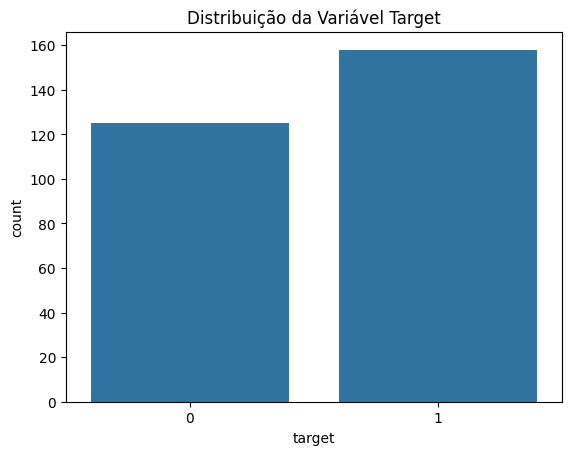

In [88]:
# Quantidade de pacientes com e sem doença cardíaca

sns.countplot(x='target', data=df)

plt.title('Distribuição da Variável Target')

plt.show()

**Gráfico agrupado**

O gráfico agrupado foi utilizado para comparar a frequência cardíaca máxima atingida entre pacientes com e sem presença de doença cardíaca.

Observa-se que os pacientes classificados com presença de doença cardíaca (target = 1) apresentaram, em média, valores mais elevados de frequência cardíaca máxima em comparação aos pacientes sem doença cardíaca (target = 0). Essa diferença pode indicar uma relação entre essa variável clínica e a condição cardiovascular analisada na base de dados.

O boxplot também permite visualizar a dispersão dos dados em cada grupo. Nota-se que ambos os grupos apresentam certa variabilidade nos valores, porém o grupo com doença cardíaca demonstra concentração maior em valores superiores da variável padronizada.

Além disso, ainda é possível observar alguns pontos isolados abaixo da distribuição principal no grupo com doença cardíaca, indicando a presença de poucos valores extremos residuais. Entretanto, esses valores aparecem em pequena quantidade e não comprometem a consistência geral da base preparada.

De maneira geral, o gráfico evidenciou diferenças no comportamento da frequência cardíaca máxima entre os grupos analisados, mostrando que essa variável possui relevância para análise dos fatores relacionados às doenças cardíacas.

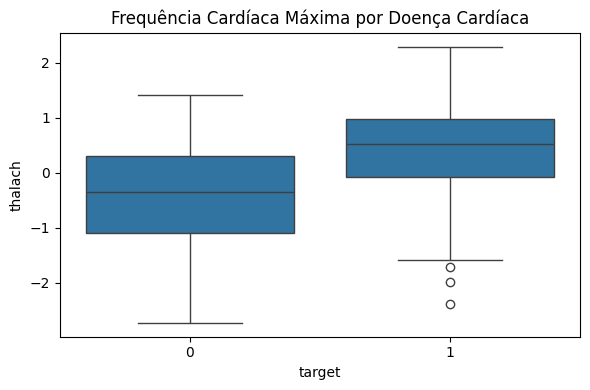

In [89]:
# Frequência cardíaca máxima por presença de doença cardíaca
plt.figure(figsize=(6,4))

sns.boxplot(x='target',
            y='thalach',
            data=df)

plt.title('Frequência Cardíaca Máxima por Doença Cardíaca')

plt.tight_layout()

plt.show()

**7. RESULTADOS DO PROCESSO DESENVOLVIDO**

Após a execução do pipeline de preparação dos dados, a base apresentou melhorias significativas em relação à qualidade, organização e consistência das informações utilizadas nas análises.

Inicialmente, foi realizada a verificação de valores ausentes utilizando a função isnull().sum(). Os resultados mostraram que a base de dados não possuía registros com dados faltantes, indicando boa integridade estrutural desde o início da análise.

Em seguida, foi realizado o tratamento de duplicidades. A análise identificou a existência de 723 registros duplicados na base original, que continha inicialmente 1025 registros. Esses dados repetidos foram removidos utilizando a função drop_duplicates(), reduzindo a quantidade de instâncias para aproximadamente 302 registros únicos e mais consistentes.

Posteriormente, foi realizado o tratamento de ruídos e outliers por meio do método do Intervalo Interquartil (IQR). Essa técnica permitiu identificar valores extremos em variáveis numéricas relacionadas a fatores cardiovasculares, como pressão arterial, colesterol sérico, frequência cardíaca máxima e alterações cardíacas induzidas por exercício. Após a remoção dos outliers, a base passou a apresentar aproximadamente 283 registros, reduzindo a influência de valores extremos nas análises estatísticas.

Também foi realizada a etapa de transformação dos dados, utilizando padronização das variáveis numéricas com o método StandardScaler. Esse processo permitiu colocar os atributos em escalas semelhantes, facilitando comparações entre variáveis e contribuindo para melhor interpretação dos dados e visualizações geradas.

Na etapa de redução de dimensionalidade e seleção de atributos, foi utilizada uma matriz de correlação para identificar as variáveis mais relevantes relacionadas à presença de doença cardíaca. Os resultados mostraram maior relevância de atributos relacionados à frequência cardíaca máxima atingida, tipo de dor no peito, angina induzida por exercício e alterações cardíacas observadas durante exercício físico.

A etapa de integração de dados não foi necessária neste projeto, pois a análise foi realizada utilizando apenas uma base de dados já consolidada.

Ao final do pipeline, a base de dados apresentou melhor qualidade estrutural, ausência de registros duplicados, redução de valores extremos e variáveis padronizadas, tornando-se mais adequada para análises estatísticas e interpretação dos fatores associados às doenças cardíacas.

In [ ]:
<div style="page-break-after: always;"></div>

<div style="page-break-after: always;"></div>